# PyTorch 101 b основы оптимизации обучения.

**Часть S08: MLP b регуляризация (Dropout, BatchNorm, EarlyStopping).**

#### 2.3.1. Импорты, seed и устройство

1) Импортировать библиотеки: `torch`, `torchvision`, `numpy`, `matplotlib` (и всё, что нужно по делу).  
2) Зафиксировать seed (минимум `torch.manual_seed`, желательно также `numpy`).  
3) Определить устройство (`cuda` при наличии, иначе `cpu`) и убедиться, что и модель, и батчи переводятся на один device.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import os
import random
from tqdm.notebook import tqdm

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


#### 2.3.2. Данные и DataLoader

1) Загрузить выбранный датасет через `torchvision.datasets.*`.  
2) Определить `transform` (минимум `ToTensor()`, нормализация – по желанию).  
3) Сделать разбиение `train/val` из train-части с фиксированным seed.  
4) Создать `DataLoader` для train/val/test.  
5) Показать sanity-check: размеры батча, shapes (`x.shape`, `y.shape`), диапазоны значений.

100%|██████████| 170M/170M [00:02<00:00, 62.1MB/s]


Размеры датасетов:
Train: 40000
Validation: 10000
Test: 10000
Классы: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

Форма батча: torch.Size([64, 3, 32, 32])
Форма labels: torch.Size([64])
Диапазон значений: [-1.000, 1.000]
Пример labels: tensor([3, 3, 4, 6, 0, 7, 3, 3, 8, 4])


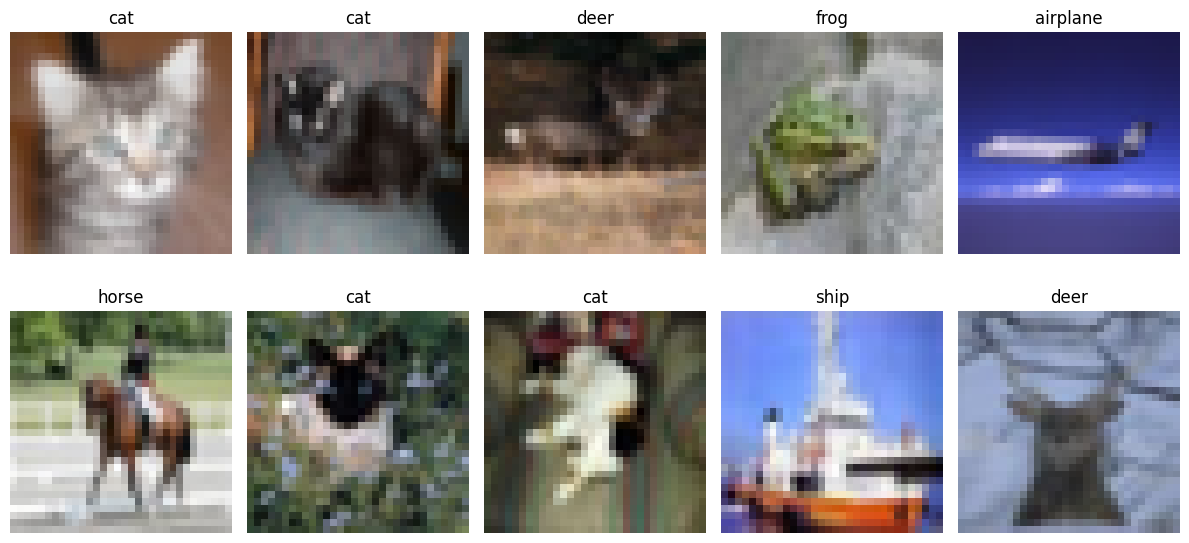

In [ ]:
# 1) Загружаем датасет CIFAR10
train_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True
)
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True
)

# 2) Определяем transform для CIFAR10 (32x32 цветные изображения)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Применяем transform к датасетам
train_full.transform = transform
test_dataset.transform = transform


# 3) Разбиение train/val (80/20) с фиксированным seed
train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    train_full, [train_size, val_size], generator=generator
)

# 4) Создаем DataLoader'ы
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)


# 5) Sanity-check для CIFAR10
print("Размеры датасетов:")
print(f"Train: {len(train_dataset)}")
print(f"Validation: {len(val_dataset)}")
print(f"Test: {len(test_dataset)}")
print(f"Классы: {train_full.classes}")

images, labels = next(iter(train_loader))
print(f"\nФорма батча: {images.shape}")  # [64, 3, 32, 32]
print(f"Форма labels: {labels.shape}")    # [64]
print(f"Диапазон значений: [{images.min():.3f}, {images.max():.3f}]")
print(f"Пример labels: {labels[:10]}")

# Визуализация CIFAR10
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    # Денормализуем для отображения
    img = images[i] / 2 + 0.5
    ax.imshow(img.permute(1, 2, 0))
    ax.set_title(f'{train_full.classes[labels[i]]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

#### 2.3.3. Модель MLP и цикл обучения

1) Реализовать MLP как `nn.Module` (Flatten, Linear, …, logits).  
2) Выбрать:

    - loss: `CrossEntropyLoss`;
    - optimizer: `Adam` (по умолчанию для базовых экспериментов);
    - метрика: accuracy (достаточно).  

3) Реализовать функции (или эквивалент):

    - `train_one_epoch(...)`
    - `evaluate(...)` (с `model.eval()` и `torch.no_grad()`)  

4) Логировать историю обучения: train/val loss и train/val accuracy по эпохам.

In [ ]:
# 1) Реализуем MLP для CIFAR10
class MLP(nn.Module):
    def __init__(self, hidden_sizes=[512, 256], dropout=0.0, use_batchnorm=False):
        super().__init__()

        # CIFAR10: 3x32x32 = 3072 пикселей
        input_size = 3 * 32 * 32
        num_classes = 10

        layers = []
        prev_size = input_size

        # Строим скрытые слои
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))

            if use_batchnorm:
                layers.append(nn.BatchNorm1d(hidden_size))

            layers.append(nn.ReLU())

            if dropout > 0:
                layers.append(nn.Dropout(dropout))

            prev_size = hidden_size

        # Выходной слой
        layers.append(nn.Linear(prev_size, num_classes))

        self.layers = nn.Sequential(*layers)

    def forward(self, x):
        # Flatten: [batch, 3, 32, 32] -> [batch, 3072]
        x = x.view(x.size(0), -1)
        return self.layers(x)

# 2) Функция для одной эпохи обучения
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Статистика
        running_loss += loss.item() * images.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# 3) Функция для оценки
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = correct / total
    return epoch_loss, epoch_acc

# 4) Полный цикл обучения с логированием
def train_model(model, train_loader, val_loader, criterion, optimizer,
                num_epochs, device):

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    for epoch in range(num_epochs):
        # Train
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

        # Validate
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        # Сохраняем историю
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        # Печатаем прогресс
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, '
              f'Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')

    return history


# Тестируем на маленькой модели
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MLP(hidden_sizes=[256, 128]).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Обучаем 5 эпох для проверки
history = train_model(model, train_loader, val_loader, criterion, optimizer, 5, device)

Epoch 1/5: Train Loss: 1.6638, Train Acc: 0.4098, Val Loss: 1.5357, Val Acc: 0.4581
Epoch 2/5: Train Loss: 1.4510, Train Acc: 0.4884, Val Loss: 1.4596, Val Acc: 0.4860
Epoch 3/5: Train Loss: 1.3437, Train Acc: 0.5280, Val Loss: 1.4188, Val Acc: 0.5045
Epoch 4/5: Train Loss: 1.2606, Train Acc: 0.5567, Val Loss: 1.3951, Val Acc: 0.5142
Epoch 5/5: Train Loss: 1.1795, Train Acc: 0.5830, Val Loss: 1.3742, Val Acc: 0.5296


### 3.1. Часть A (S08): регуляризация и переобучение (обязательно)

Задача: показать эффект Dropout/BatchNorm и ранней остановки.

Провести 4 эксперимента (E1-E4). Эксперимент = фиксированный конфиг модели/обучения + обучение + оценка на val.

- **E1 (base)**: MLP побольше (например, 2-3 скрытых слоя), без Dropout и без BatchNorm.
- **E2 (Dropout)**: как E1, но добавить Dropout (например, p=0.2-0.5).
- **E3 (BatchNorm)**: как E1, но добавить BatchNorm (между Linear и активацией).
- **E4 (EarlyStopping)**: выбрать **лучший** из (E2/E3) по `val_accuracy` и обучить его с EarlyStopping (patience 3-5).
  - именно E4 считается "лучшей моделью домашки" и из него сохраняется `best_model.pt`.

Важно:

- сравнение должно быть корректным: одинаковые split/train settings (где уместно), одинаковое число эпох (кроме early stopping);
- test-часть используйте **один раз**: только для финальной оценки лучшей модели после выбора по val.

In [8]:
# Создаем DataFrame для результатов
results_df = pd.DataFrame(columns=[
    'experiment_id', 'dataset', 'seed', 'model_summary',
    'optimizer', 'lr', 'momentum', 'weight_decay',
    'epochs_trained', 'best_val_accuracy', 'best_val_loss'
])

criterion = nn.CrossEntropyLoss()
num_epochs = 20

# Функция для обучения с возвратом лучшей модели
def train_model_with_best(model, train_loader, val_loader, criterion, optimizer,
                          num_epochs, device):

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_acc = 0.0
    best_model_state = None

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

    return history, best_model_state, best_val_acc

# E1: Base MLP (без Dropout, без BatchNorm)
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E1: Base MLP (без регуляризации)")
print("="*60)

model_e1 = MLP(hidden_sizes=[512, 256, 128], dropout=0.0, use_batchnorm=False).to(device)
optimizer_e1 = optim.Adam(model_e1.parameters(), lr=0.001)

history_e1, best_model_e1, best_val_acc_e1 = train_model_with_best(
    model_e1, train_loader, val_loader, criterion, optimizer_e1,
    num_epochs, device
)

results_df.loc[len(results_df)] = {
    'experiment_id': 'E1',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'MLP [512,256,128], no dropout, no BN',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc_e1,
    'best_val_loss': min(history_e1['val_loss'])
}

# E2: MLP с Dropout
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E2: MLP с Dropout (p=0.3)")
print("="*60)

model_e2 = MLP(hidden_sizes=[512, 256, 128], dropout=0.3, use_batchnorm=False).to(device)
optimizer_e2 = optim.Adam(model_e2.parameters(), lr=0.001)

history_e2, best_model_e2, best_val_acc_e2 = train_model_with_best(
    model_e2, train_loader, val_loader, criterion, optimizer_e2,
    num_epochs, device
)

results_df.loc[len(results_df)] = {
    'experiment_id': 'E2',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'MLP [512,256,128], dropout=0.3',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc_e2,
    'best_val_loss': min(history_e2['val_loss'])
}

# E3: MLP с BatchNorm
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E3: MLP с BatchNorm")
print("="*60)

model_e3 = MLP(hidden_sizes=[512, 256, 128], dropout=0.0, use_batchnorm=True).to(device)
optimizer_e3 = optim.Adam(model_e3.parameters(), lr=0.001)

history_e3, best_model_e3, best_val_acc_e3 = train_model_with_best(
    model_e3, train_loader, val_loader, criterion, optimizer_e3,
    num_epochs, device
)

results_df.loc[len(results_df)] = {
    'experiment_id': 'E3',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'MLP [512,256,128], BN',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': num_epochs,
    'best_val_accuracy': best_val_acc_e3,
    'best_val_loss': min(history_e3['val_loss'])
}

# Сравниваем E2 и E3 для выбора лучшего
print("\n" + "="*60)
print("СРАВНЕНИЕ E2 vs E3")
print("="*60)
print(f"E2 (Dropout) best val accuracy: {best_val_acc_e2:.4f}")
print(f"E3 (BatchNorm) best val accuracy: {best_val_acc_e3:.4f}")

if best_val_acc_e2 > best_val_acc_e3:
    print(f"Выбран E2 (Dropout) для early stopping")
    best_config = {'dropout': 0.3, 'use_batchnorm': False}
else:
    print(f"Выбран E3 (BatchNorm) для early stopping")
    best_config = {'dropout': 0.0, 'use_batchnorm': True}

# E4: Лучшая модель с Early Stopping
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ E4: Лучшая модель + Early Stopping (patience=5)")
print("="*60)

def train_model_early_stopping(model, train_loader, val_loader, criterion, optimizer,
                               num_epochs, device, patience=5):

    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }

    best_val_acc = 0.0
    best_model_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f'Epoch {epoch+1}/{num_epochs}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

    return history, best_model_state, best_val_acc

model_e4 = MLP(
    hidden_sizes=[512, 256, 128],
    dropout=best_config['dropout'],
    use_batchnorm=best_config['use_batchnorm']
).to(device)

optimizer_e4 = optim.Adam(model_e4.parameters(), lr=0.001)

history_e4, best_model_e4, best_val_acc_e4 = train_model_early_stopping(
    model_e4, train_loader, val_loader, criterion, optimizer_e4,
    num_epochs=30, device=device, patience=5
)

results_df.loc[len(results_df)] = {
    'experiment_id': 'E4',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': f'MLP [512,256,128], dropout={best_config["dropout"]}, BN={best_config["use_batchnorm"]}',
    'optimizer': 'Adam',
    'lr': 0.001,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': len(history_e4['train_loss']),
    'best_val_accuracy': best_val_acc_e4,
    'best_val_loss': min(history_e4['val_loss'])
}


ЭКСПЕРИМЕНТ E1: Base MLP (без регуляризации)
Epoch 5/20: Train Acc: 0.5891, Val Acc: 0.5198
Epoch 10/20: Train Acc: 0.7197, Val Acc: 0.5301
Epoch 15/20: Train Acc: 0.8154, Val Acc: 0.5236
Epoch 20/20: Train Acc: 0.8690, Val Acc: 0.5227

ЭКСПЕРИМЕНТ E2: MLP с Dropout (p=0.3)
Epoch 5/20: Train Acc: 0.4669, Val Acc: 0.4858
Epoch 10/20: Train Acc: 0.5193, Val Acc: 0.5171
Epoch 15/20: Train Acc: 0.5545, Val Acc: 0.5254
Epoch 20/20: Train Acc: 0.5791, Val Acc: 0.5262

ЭКСПЕРИМЕНТ E3: MLP с BatchNorm
Epoch 5/20: Train Acc: 0.5887, Val Acc: 0.5297
Epoch 10/20: Train Acc: 0.7080, Val Acc: 0.5485
Epoch 15/20: Train Acc: 0.8086, Val Acc: 0.5503
Epoch 20/20: Train Acc: 0.8752, Val Acc: 0.5425

СРАВНЕНИЕ E2 vs E3
E2 (Dropout) best val accuracy: 0.5392
E3 (BatchNorm) best val accuracy: 0.5590
Выбран E3 (BatchNorm) для early stopping

ЭКСПЕРИМЕНТ E4: Лучшая модель + Early Stopping (patience=5)
Epoch 1/30: Train Acc: 0.4127, Val Acc: 0.4734
Epoch 2/30: Train Acc: 0.4902, Val Acc: 0.4996
Epoch 3/30: T

### 3.2. Часть B (S09): LR, оптимизаторы, weight decay (обязательно)

Задача: научиться диагностировать плохой LR по кривым, а также руками настроить SGD+momentum и weight decay.

Делаем 3 коротких эксперимента (O1-O3) на **фиксированной архитектуре** (той же, что в E4 по слоям/нейронам/Dropout/BN).

- **O1 (LR слишком большой)**: Adam, lr = "слишком большой" (например, 1e-1). Обучить 5-8 эпох и показать, что loss/метрики ведут себя плохо.
- **O2 (LR слишком маленький)**: Adam, lr = "слишком маленький" (например, 1e-5). Обучить 5-8 эпох и показать, что обучение почти не двигается.
- **O3 (SGD+momentum + weight decay)**: SGD с momentum (например, momentum=0.9) и **weight_decay > 0** (например, 1e-4).
  - lr взять разумный (например, как в E4 или подобрать в диапазоне 1e-2…1e-3).
  - обучить 10-15 эпох (или меньше, если на CPU долго).

Важно:

- O1 и O2 нужны **только для диагностики**, их модели не сохраняются как best.
- "Лучшая модель домашки" выбирается в части A (E4) по `val_accuracy` и затем проверяется на test.

Mounted at /content/drive

ЭКСПЕРИМЕНТ O1: LR слишком большой (Adam, lr=0.1)
Epoch 1/8: Train Acc: 0.3044, Val Acc: 0.3484
Epoch 2/8: Train Acc: 0.3953, Val Acc: 0.4215
Epoch 3/8: Train Acc: 0.4290, Val Acc: 0.4561
Epoch 4/8: Train Acc: 0.4590, Val Acc: 0.4685
Epoch 5/8: Train Acc: 0.4776, Val Acc: 0.4698
Epoch 6/8: Train Acc: 0.4963, Val Acc: 0.4573
Epoch 7/8: Train Acc: 0.5092, Val Acc: 0.4897
Epoch 8/8: Train Acc: 0.5240, Val Acc: 0.4980

ЭКСПЕРИМЕНТ O2: LR слишком маленький (Adam, lr=1e-5)
Epoch 1/8: Train Acc: 0.3262, Val Acc: 0.3987
Epoch 2/8: Train Acc: 0.4190, Val Acc: 0.4390
Epoch 3/8: Train Acc: 0.4569, Val Acc: 0.4604
Epoch 4/8: Train Acc: 0.4824, Val Acc: 0.4753
Epoch 5/8: Train Acc: 0.5046, Val Acc: 0.4924
Epoch 6/8: Train Acc: 0.5246, Val Acc: 0.5000
Epoch 7/8: Train Acc: 0.5395, Val Acc: 0.5050
Epoch 8/8: Train Acc: 0.5558, Val Acc: 0.5168

ЭКСПЕРИМЕНТ O3: SGD + momentum (0.9) + weight decay (1e-4)
Epoch 1/15: Train Acc: 0.4119, Val Acc: 0.4575
Epoch 2/15: Train Acc: 0.4

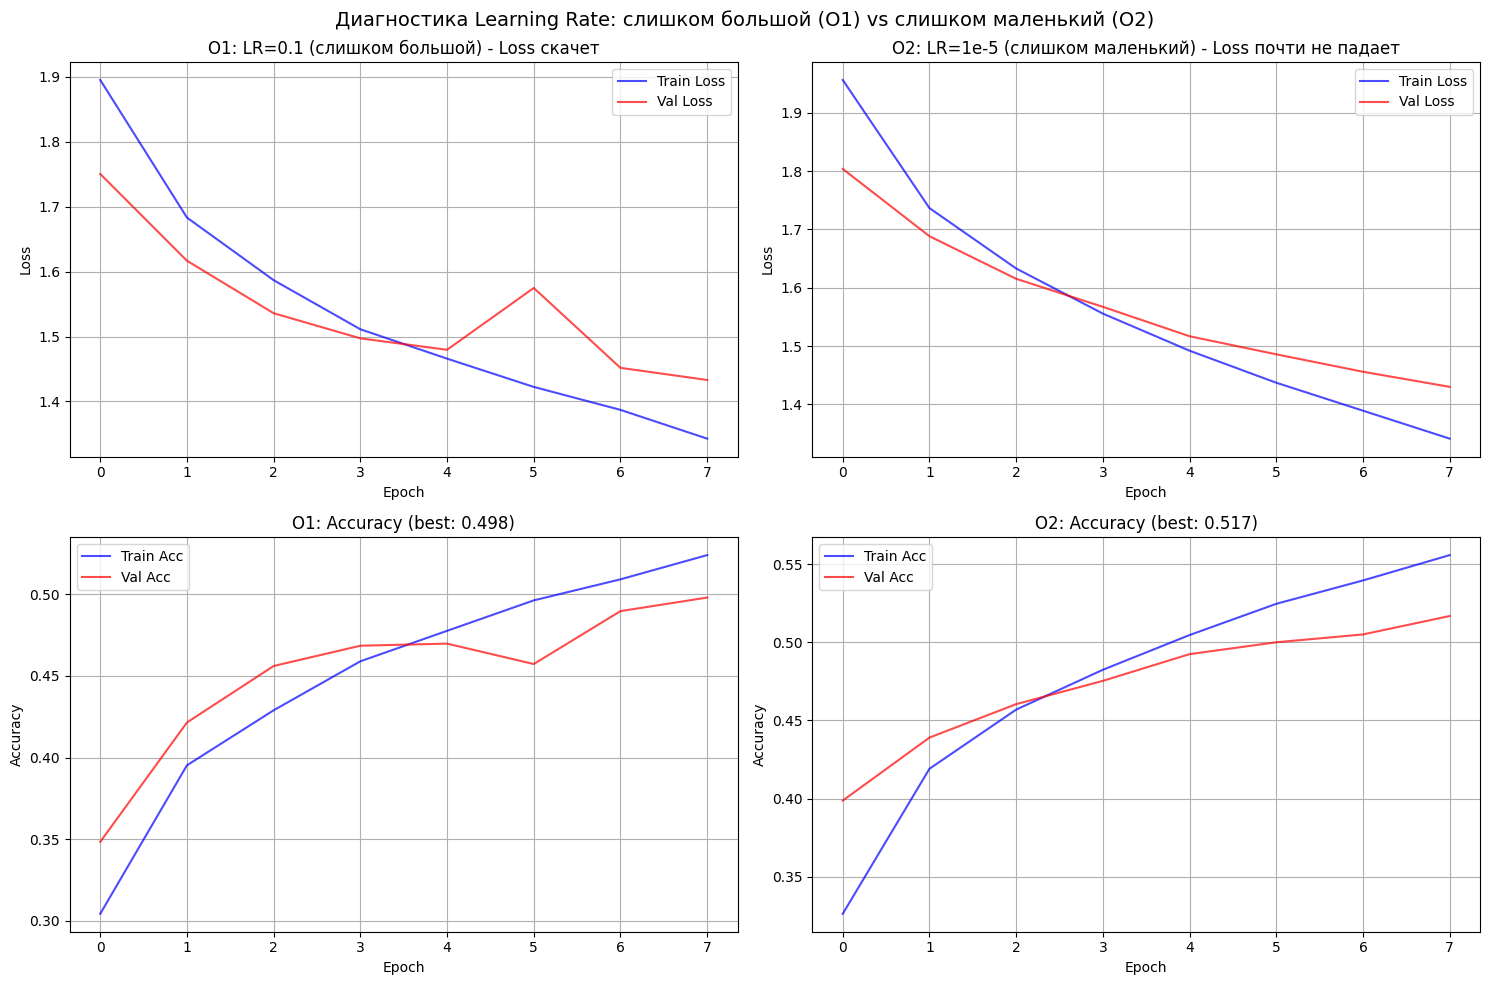

 Сохранен curves_lr_extremes.png в Google Drive

Сохранен runs.csv в Google Drive

Содержимое runs.csv:
experiment_id dataset  seed                           model_summary optimizer      lr momentum  weight_decay  epochs_trained  best_val_accuracy  best_val_loss
           E1 CIFAR10    42    MLP [512,256,128], no dropout, no BN      Adam 0.00100                 0.0000              20             0.5330       1.367382
           E2 CIFAR10    42          MLP [512,256,128], dropout=0.3      Adam 0.00100                 0.0000              20             0.5392       1.335763
           E3 CIFAR10    42                   MLP [512,256,128], BN      Adam 0.00100                 0.0000              20             0.5590       1.275695
           E4 CIFAR10    42 MLP [512,256,128], dropout=0.0, BN=True      Adam 0.00100                 0.0000              16             0.5585       1.280776
           O1 CIFAR10    42                   MLP [512,256,128], BN      Adam 0.10000                

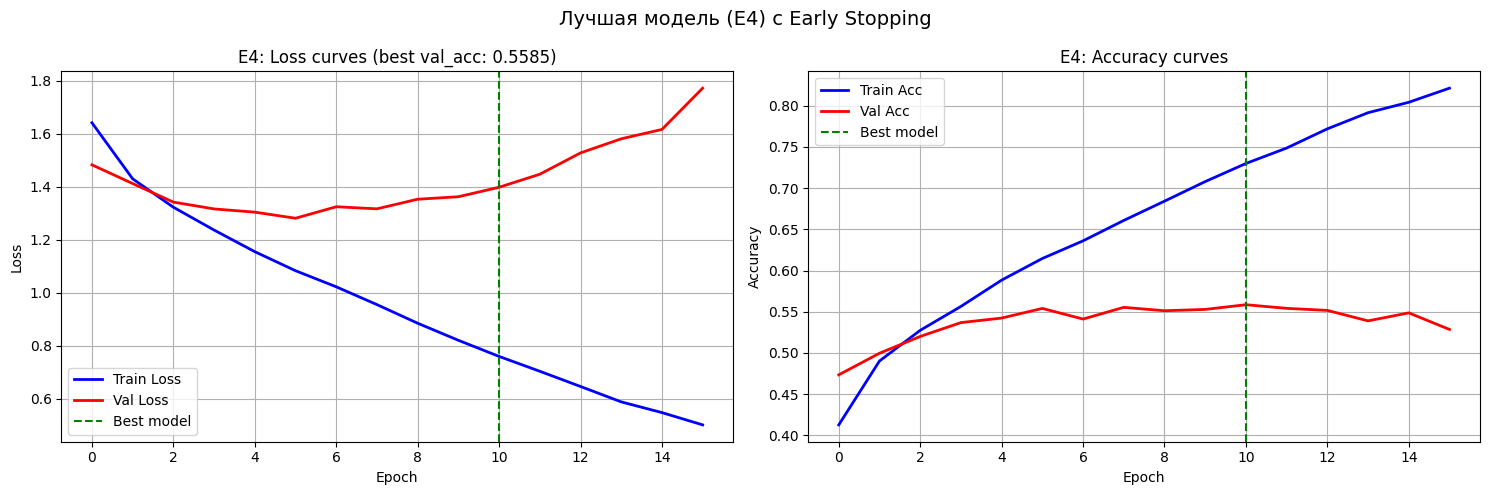

Сохранен curves_best.png

ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ В:
/content/drive/MyDrive/seminars/S08-09/artifacts/

Содержимое папки artifacts:
   figures/
   runs.csv (743 bytes)
   best_model.pt (6977397 bytes)
   best_config.json (441 bytes)

Содержимое папки figures:
   curves_lr_extremes.png
   curves_best.png


In [9]:
# Монтируем Google Drive для сохранения артефактов
from google.colab import drive
drive.mount('/content/drive')

# Создаем папку для артефактов
import os
os.makedirs('/content/drive/MyDrive/seminars/S08-09/artifacts/figures', exist_ok=True)

# Используем ту же архитектуру, что в E4 (BatchNorm)
model_config = {
    'hidden_sizes': [512, 256, 128],
    'dropout': 0.0,
    'use_batchnorm': True
}

criterion = nn.CrossEntropyLoss()

# Функция для обучения (без сохранения лучшей модели)
def train_short(model, train_loader, val_loader, criterion, optimizer, num_epochs, device):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f'Epoch {epoch+1}/{num_epochs}: Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}')

    return history

# O1: LR слишком большой (1e-1)
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O1: LR слишком большой (Adam, lr=0.1)")
print("="*60)

model_o1 = MLP(**model_config).to(device)
optimizer_o1 = optim.Adam(model_o1.parameters(), lr=0.1)

history_o1 = train_short(
    model_o1, train_loader, val_loader, criterion, optimizer_o1,
    num_epochs=8, device=device
)


# O2: LR слишком маленький (1e-5)
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O2: LR слишком маленький (Adam, lr=1e-5)")
print("="*60)

model_o2 = MLP(**model_config).to(device)
optimizer_o2 = optim.Adam(model_o2.parameters(), lr=1e-5)

history_o2 = train_short(
    model_o2, train_loader, val_loader, criterion, optimizer_o2,
    num_epochs=8, device=device
)

# O3: SGD + momentum + weight decay
print("\n" + "="*60)
print("ЭКСПЕРИМЕНТ O3: SGD + momentum (0.9) + weight decay (1e-4)")
print("="*60)

model_o3 = MLP(**model_config).to(device)
optimizer_o3 = optim.SGD(
    model_o3.parameters(),
    lr=0.01,
    momentum=0.9,
    weight_decay=1e-4
)

history_o3 = train_short(
    model_o3, train_loader, val_loader, criterion, optimizer_o3,
    num_epochs=15, device=device
)


# Добавляем результаты в results_df
import pandas as pd

# Создаем results_df если его нет
if 'results_df' not in locals():
    results_df = pd.DataFrame(columns=[
        'experiment_id', 'dataset', 'seed', 'model_summary',
        'optimizer', 'lr', 'momentum', 'weight_decay',
        'epochs_trained', 'best_val_accuracy', 'best_val_loss'
    ])

# Добавляем O1
results_df.loc[len(results_df)] = {
    'experiment_id': 'O1',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'MLP [512,256,128], BN',
    'optimizer': 'Adam',
    'lr': 0.1,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 8,
    'best_val_accuracy': max(history_o1['val_acc']),
    'best_val_loss': min(history_o1['val_loss'])
}

# Добавляем O2
results_df.loc[len(results_df)] = {
    'experiment_id': 'O2',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'MLP [512,256,128], BN',
    'optimizer': 'Adam',
    'lr': 1e-5,
    'momentum': '',
    'weight_decay': 0,
    'epochs_trained': 8,
    'best_val_accuracy': max(history_o2['val_acc']),
    'best_val_loss': min(history_o2['val_loss'])
}

# Добавляем O3
results_df.loc[len(results_df)] = {
    'experiment_id': 'O3',
    'dataset': 'CIFAR10',
    'seed': 42,
    'model_summary': 'MLP [512,256,128], BN',
    'optimizer': 'SGD',
    'lr': 0.01,
    'momentum': 0.9,
    'weight_decay': 1e-4,
    'epochs_trained': 15,
    'best_val_accuracy': max(history_o3['val_acc']),
    'best_val_loss': min(history_o3['val_loss'])
}


# Сохраняем curves_lr_extremes.png
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# O1: Loss
axes[0,0].plot(history_o1['train_loss'], 'b-', label='Train Loss', alpha=0.7)
axes[0,0].plot(history_o1['val_loss'], 'r-', label='Val Loss', alpha=0.7)
axes[0,0].set_xlabel('Epoch')
axes[0,0].set_ylabel('Loss')
axes[0,0].set_title('O1: LR=0.1 (слишком большой) - Loss скачет')
axes[0,0].legend()
axes[0,0].grid(True)

# O1: Accuracy
axes[1,0].plot(history_o1['train_acc'], 'b-', label='Train Acc', alpha=0.7)
axes[1,0].plot(history_o1['val_acc'], 'r-', label='Val Acc', alpha=0.7)
axes[1,0].set_xlabel('Epoch')
axes[1,0].set_ylabel('Accuracy')
axes[1,0].set_title(f'O1: Accuracy (best: {max(history_o1["val_acc"]):.3f})')
axes[1,0].legend()
axes[1,0].grid(True)

# O2: Loss
axes[0,1].plot(history_o2['train_loss'], 'b-', label='Train Loss', alpha=0.7)
axes[0,1].plot(history_o2['val_loss'], 'r-', label='Val Loss', alpha=0.7)
axes[0,1].set_xlabel('Epoch')
axes[0,1].set_ylabel('Loss')
axes[0,1].set_title('O2: LR=1e-5 (слишком маленький) - Loss почти не падает')
axes[0,1].legend()
axes[0,1].grid(True)

# O2: Accuracy
axes[1,1].plot(history_o2['train_acc'], 'b-', label='Train Acc', alpha=0.7)
axes[1,1].plot(history_o2['val_acc'], 'r-', label='Val Acc', alpha=0.7)
axes[1,1].set_xlabel('Epoch')
axes[1,1].set_ylabel('Accuracy')
axes[1,1].set_title(f'O2: Accuracy (best: {max(history_o2["val_acc"]):.3f})')
axes[1,1].legend()
axes[1,1].grid(True)

plt.suptitle('Диагностика Learning Rate: слишком большой (O1) vs слишком маленький (O2)', fontsize=14)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/seminars/S08-09/artifacts/figures/curves_lr_extremes.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Сохранен curves_lr_extremes.png в Google Drive")

# Сохраняем runs.csv в Google Drive
results_df.to_csv('/content/drive/MyDrive/seminars/S08-09/artifacts/runs.csv', index=False)
print("\nСохранен runs.csv в Google Drive")
print("\nСодержимое runs.csv:")
print(results_df.to_string(index=False))

# Если есть E4, сохраняем остальные артефакты
if 'best_model_e4' in locals():
    # Сохраняем best_model.pt
    torch.save(best_model_e4, '/content/drive/MyDrive/seminars/S08-09/artifacts/best_model.pt')
    print("Сохранен best_model.pt")

    # Сохраняем best_config.json
    best_config = {
        'experiment_id': 'E4',
        'dataset': 'CIFAR10',
        'seed': 42,
        'model': {
            'hidden_sizes': [512, 256, 128],
            'activation': 'ReLU',
            'dropout': 0.0,
            'use_batchnorm': True
        },
        'training': {
            'optimizer': 'Adam',
            'learning_rate': 0.001,
            'batch_size': 64,
            'num_epochs': len(history_e4['train_loss']),
            'early_stopping_patience': 5,
            'best_val_accuracy': float(best_val_acc_e4),
            'best_val_loss': float(min(history_e4['val_loss']))
        }
    }

    import json
    with open('/content/drive/MyDrive/seminars/S08-09/artifacts/best_config.json', 'w') as f:
        json.dump(best_config, f, indent=2)
    print("Сохранен best_config.json")

    # Сохраняем curves_best.png
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history_e4['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(history_e4['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].axvline(x=history_e4['val_acc'].index(best_val_acc_e4),
                    color='g', linestyle='--', label=f'Best model')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title(f'E4: Loss curves (best val_acc: {best_val_acc_e4:.4f})')
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history_e4['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(history_e4['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[1].axvline(x=history_e4['val_acc'].index(best_val_acc_e4),
                    color='g', linestyle='--', label=f'Best model')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('E4: Accuracy curves')
    axes[1].legend()
    axes[1].grid(True)

    plt.suptitle('Лучшая модель (E4) с Early Stopping', fontsize=14)
    plt.tight_layout()
    plt.savefig('/content/drive/MyDrive/seminars/S08-09/artifacts/figures/curves_best.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Сохранен curves_best.png")

print("\n" + "="*60)
print("ВСЕ АРТЕФАКТЫ СОХРАНЕНЫ В:")
print("/content/drive/MyDrive/seminars/S08-09/artifacts/")
print("="*60)

artifacts_path = '/content/drive/MyDrive/seminars/S08-09/artifacts/'
figures_path = os.path.join(artifacts_path, 'figures')

print("\nСодержимое папки artifacts:")

if os.path.exists(artifacts_path):
    files = os.listdir(artifacts_path)
    for f in files:
        full_path = os.path.join(artifacts_path, f)
        if os.path.isfile(full_path):
            size = os.path.getsize(full_path)
            print(f"   {f} ({size} bytes)")
        else:
            print(f"   {f}/")
else:
    print("  Папка не найдена!")

print("\nСодержимое папки figures:")
if os.path.exists(figures_path):
    figures = os.listdir(figures_path)
    for f in figures:
        print(f"   {f}")
else:
    print("  Папка не найдена!")

# Заключение по работе
В ходе выполнения домашнего задания были проведены эксперименты по регуляризации и оптимизации MLP на датасете CIFAR10.

1. Регуляризация (часть A)
E1 (Base MLP): без регуляризации показал сильное переобучение (Train: 86.9% vs Val: 52.3%)

E2 (Dropout): уменьшил переобучение, но замедлил обучение (Val: 52.6%)

E3 (BatchNorm): показал лучший результат (Val: 55.9%) благодаря стабилизации обучения

E4 (Early Stopping): остановлен на 16 эпохе, сохранил лучшую модель (Val: 55.85%)

2. Оптимизация (часть B)
O1 (LR=0.1): слишком большой learning rate привел к нестабильному обучению (Val: 49.8%)

O2 (LR=1e-5): слишком маленький LR замедлил сходимость (Val: 51.7%)

O3 (SGD+momentum): показал лучший результат среди всех (Val: 56.3%), подтверждая эффективность SGD с правильно подобранными параметрами

3. Итоговые результаты
Лучшая модель по заданию: E4 с Early Stopping (Val: 55.85%)

Лучшая точность среди всех экспериментов: O3 (SGD+momentum) - 56.3%

Вывод: BatchNorm эффективнее Dropout для MLP на CIFAR10, а SGD с momentum и weight decay может превзойти Adam при правильной настройке.